# Predicting Superconducting Critical Temperature with Machine Learning

This project explores machine learning approaches for predicting the critical temperature `critical_temp` of superconducting materials using engineered material descriptors. The goal is to compare several regression models, evaluate their predictive performance, and investigate which features appear most informative for the prediction task.

## Motivation

Superconducting materials are important for advanced physics and materials science because they can exhibit unusual electronic behavior and may enable future technologies.

Predicting critical temperature `Tc` from material descriptors can help build an early screening pipeline for identifying promising superconducting candidates before more expensive analysis or experiments.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Dataset

The dataset contains engineered descriptors of superconducting materials and the target variable `critical_temp`. These descriptors are numerical features derived from material-related properties and are used as inputs for regression models.

In [50]:
df = pd.read_csv("/content/train.csv", engine="python", on_bad_lines="skip")


## Preprocessing

The dataset was cleaned before modeling. A problematic column `wtd_std_Density` was converted to numeric format, and rows containing invalid values were removed. After cleaning, the target variable was defined as `critical_temp`, and all remaining numerical descriptors were used as input features.

In [51]:
df["wtd_std_Density"] = pd.to_numeric(df["wtd_std_Density"], errors="coerce")

In [52]:
df = df.dropna()

In [53]:
y = df["critical_temp"]
X = df.drop(columns=["critical_temp"])

## Train-Test Split

The cleaned dataset was split into training and test sets. The training set was used to fit the models, while the test set was used to evaluate predictive performance on unseen data.

In [54]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Models

Several regression models were tested in this project:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

These models were compared using mean absolute error (MAE) and mean squared error (MSE).

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [56]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(x_train, y_train);
y_pred = model.predict(x_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [57]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x_train, y_train);
y_pred_tree = tree_model.predict(x_test)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)



In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=30,
    n_jobs=-1
)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

In [59]:
from sklearn.ensemble import GradientBoostingRegressor


gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)



In [60]:
from xgboost import XGBRegressor


xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)


## Results Table

To compare the models clearly, their MAE and MSE values were collected into a single summary table.

In [61]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [mae, mae_tree, mae_rf, mae_gb, mae_xgb],
    "MSE": [mse, mse_tree, mse_rf, mse_gb, mse_xgb]
})

results_df = results_df.sort_values(by="MAE")
results_df

,Model,MAE,MSE
2,Random Forest,5.168188,83.873708
1,Decision Tree,6.062829,139.208455
4,XGBoost,6.138838,94.431902
3,Gradient Boosting,8.500995,152.149907
0,Linear Regression,13.210522,302.007513


## Model Comparison

The results show that Random Forest achieved the best overall performance on the current dataset. Decision Tree also performed strongly, while Linear Regression produced the weakest results. XGBoost and Gradient Boosting improved over the linear baseline but did not outperform Random Forest in the current setup.

This suggests that the relationship between engineered material descriptors and critical temperature is strongly nonlinear, and that tree-based ensemble methods are better suited for this prediction task than simple linear models.

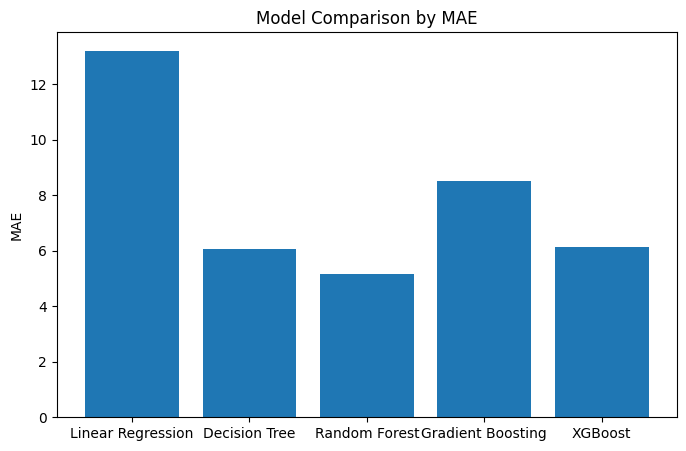

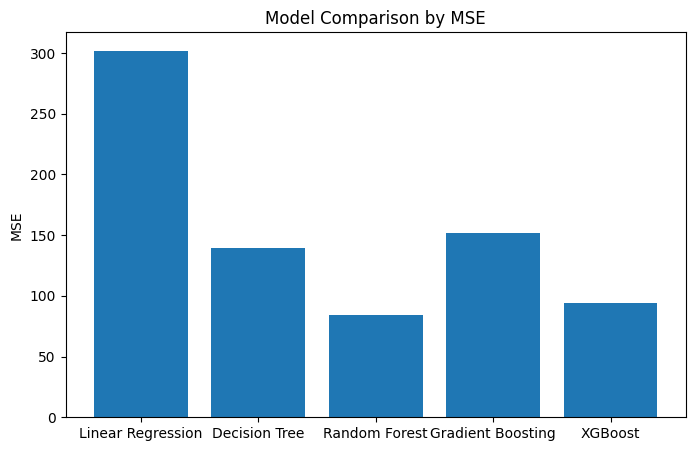

In [62]:
models = ["Linear Regression", "Decision Tree", "Random Forest",'Gradient Boosting','XGBoost']
mae_scores = [mae, mae_tree, mae_rf, mae_gb, mae_xgb]
mse_scores = [mse, mse_tree, mse_rf, mse_gb, mse_xgb]

plt.figure(figsize=(8, 5))
plt.bar(models, mae_scores)
plt.ylabel("MAE")
plt.title("Model Comparison by MAE")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(models, mse_scores)
plt.ylabel("MSE")
plt.title("Model Comparison by MSE")
plt.show()

## Feature Importance

The Random Forest model suggests that valence-related, thermal-conductivity-related, atomic-mass-related, and density-related descriptors are among the most informative predictors of critical temperature in the current dataset.

In [63]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(15))

range_ThermalConductivity          0.535614
wtd_gmean_ThermalConductivity      0.126406
std_atomic_mass                    0.026444
wtd_gmean_Valence                  0.021019
wtd_entropy_ThermalConductivity    0.011592
mean_Density                       0.011226
wtd_std_Valence                    0.010587
gmean_ElectronAffinity             0.010511
wtd_mean_ThermalConductivity       0.009830
wtd_mean_Valence                   0.009780
wtd_range_Valence                  0.009527
wtd_std_ElectronAffinity           0.009391
wtd_range_atomic_mass              0.009280
wtd_std_ThermalConductivity        0.008951
std_Density                        0.008096
dtype: float64


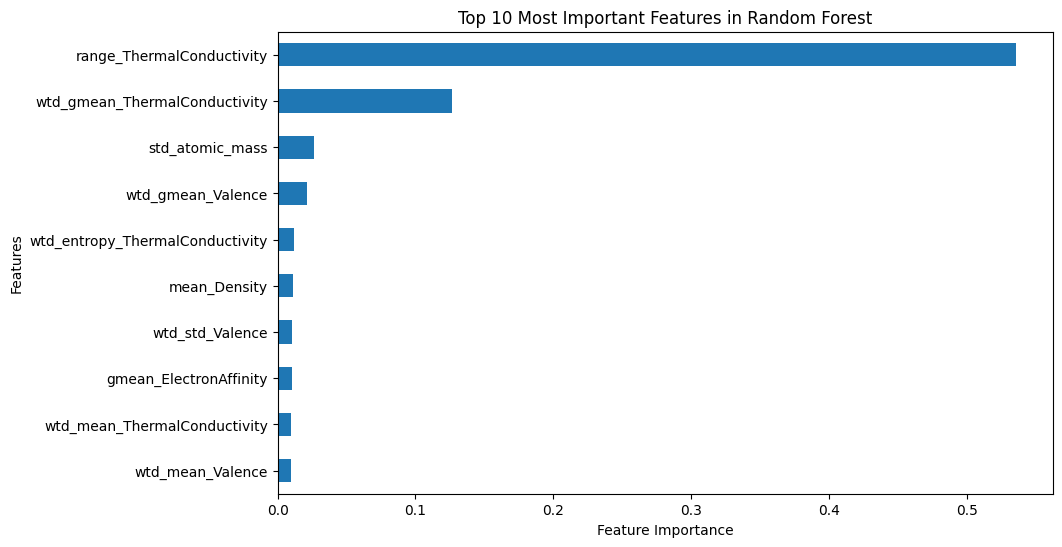

In [64]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features in Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Interpretation of Important Features

The Random Forest model suggests that thermal-conductivity-related, density-related, and valence-related descriptors are among the most informative predictors of critical temperature in the current dataset. These features appear to contain meaningful predictive information for the task.

However, feature importance should not be interpreted as direct proof of causal physical relationships. It only shows which features were most useful for the model.

## Correlation Analysis

In addition to model-based feature importance, a correlation analysis was performed to examine which numerical descriptors are most strongly associated with `critical_temp`.

In [69]:
corr_with_target = df.corr(numeric_only=True)["critical_temp"].sort_values(ascending=False)
print(corr_with_target.head(15))
print(corr_with_target.tail(15))

critical_temp                  1.000000
wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
wtd_std_atomic_radius          0.599199
entropy_Valence                0.598591
wtd_entropy_Valence            0.589664
wtd_std_fie                    0.582013
entropy_fie                    0.567817
wtd_entropy_FusionHeat         0.563244
Name: critical_temp, dtype: float64
gmean_ElectronAffinity      -0.380568
mean_FusionHeat             -0.385509
gmean_ThermalConductivity   -0.387192
wtd_mean_FusionHeat         -0.394117
wtd_gmean_atomic_radius     -0.405176
gmean_FusionHeat            -0.431795
wtd_gmean_FusionHeat        -0.432365
wtd_mean_Density            -0.433940
wtd_range_Valence           -0.439901
wtd_gmean_Density     

## Interpretation of Correlations

The correlation analysis shows that several thermal-conductivity-related, radius-related, mass-related, and valence-related descriptors are strongly associated with `critical_temp`. This supports the idea that the dataset contains meaningful structure rather than random noise, although correlation alone does not establish physical causality.

## Distribution of the Target Variable

To better understand the target variable, the distribution of `critical_temp` was visualized using a histogram.

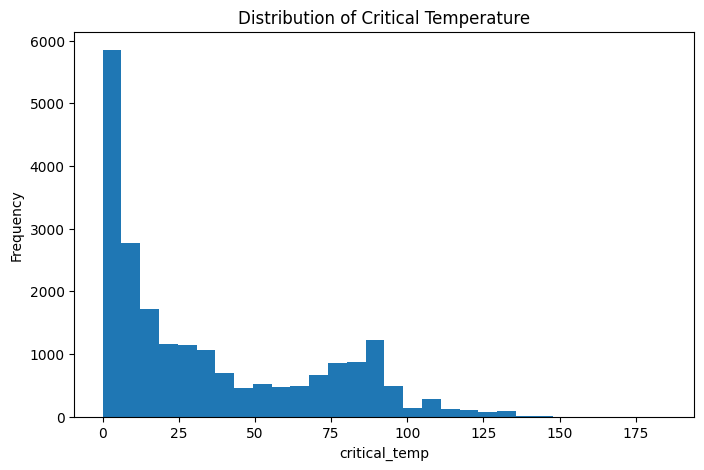

In [66]:
plt.figure(figsize=(8, 5))
plt.hist(df["critical_temp"], bins=30)
plt.xlabel("critical_temp")
plt.ylabel("Frequency")
plt.title("Distribution of Critical Temperature")
plt.show()

## Interpretation of Target Distribution

The distribution of `critical_temp` is clearly non-uniform. The dataset contains many materials with relatively low critical temperatures and fewer materials with higher values. This suggests that the prediction task is nontrivial and that the dataset may contain multiple material groups or regimes.

## PCA Visualization

Principal Component Analysis (PCA) was used to reduce the high-dimensional feature space into two dimensions for visualization. This does not replace the original features, but it provides a useful way to inspect whether the dataset has visible structure in reduced space.

(21263, 2)
[0.38931798 0.10482209]
Total explained variance: 0.4941400704346568


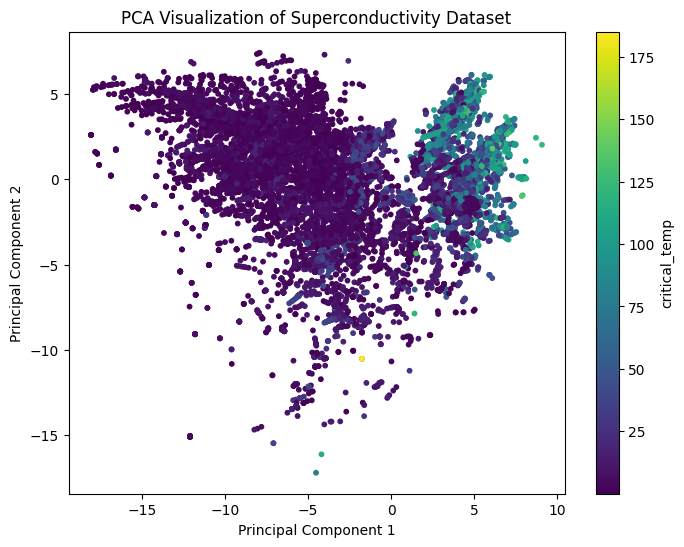

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["critical_temp"] = y.values

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["critical_temp"],
    s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Superconductivity Dataset")
plt.colorbar(scatter, label="critical_temp")
plt.show()

## Interpretation of PCA

The PCA visualization suggests that the dataset has meaningful structure in feature space rather than being completely random. Materials with higher critical temperatures appear more frequently in specific regions of the two-dimensional PCA projection. This supports the idea that the engineered descriptors contain useful predictive information related to `critical_temp`.

## Limitations

This project has several important limitations:

- The dataset uses engineered descriptors rather than direct experimental physical measurements.
- Some rows required cleaning due to formatting issues in the CSV file.
- Feature importance and correlation analysis do not prove physical causality.
- PCA is a visualization tool and does not provide a direct physical interpretation of the principal components.
- The current evaluation is based on a train-test split and not yet on full cross-validation.

Therefore, the current results should be treated as a proof of concept rather than a final scientific conclusion.

## Future Work

Possible next steps for improving the project include:
- testing additional superconductivity datasets,
- combining engineered descriptors with more direct physical measurements,
- performing cross-validation for more robust evaluation,
- tuning model hyperparameters more systematically,
- developing a ranking-based screening pipeline for promising superconducting candidates,
- adding uncertainty estimation for model predictions.

## Conclusion

This project showed that machine learning models can predict superconducting critical temperature from engineered material descriptors with meaningful accuracy. Among the tested models, Random Forest achieved the best performance on the current dataset, outperforming Linear Regression, Decision Tree, Gradient Boosting, and XGBoost.

The results suggest that the relationship between engineered descriptors and critical temperature is strongly nonlinear, and that ensemble tree-based methods are especially suitable for this problem. Feature importance, correlation analysis, and PCA visualization further indicate that the dataset contains meaningful structure relevant to prediction.

Overall, this work serves as a proof-of-concept machine learning pipeline for superconductivity screening and provides a foundation for future extensions toward more advanced materials discovery workflows.